In [1]:
# --- Setup: locate the dataset (run once per session) ---
# Colab: mount Drive, unzip MyDrive/data.zip onto the VM's local disk.
# fablab workstation (WSL2 / GTX 1080): everything durable lives in ~/navlori and
# /content is a symlink to it, so every path in this notebook works on both machines.
import importlib.util, os, sys, time, zipfile
COLAB = (importlib.util.find_spec("google") is not None
         and importlib.util.find_spec("google.colab") is not None)
if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    ROOT = os.path.expanduser("~/navlori")
    if not os.path.islink("/content"):
        os.symlink(ROOT, "/content")

DATA = "/content/data/run2"
if not os.path.isdir(DATA):
    t = time.time()
    with zipfile.ZipFile("/content/drive/MyDrive/data.zip" if COLAB else "/content/data.zip") as z:
        z.extractall("/content")
    print(f"unzipped to {DATA} in {time.time() - t:.0f}s")

sys.path.append("/content/data/scripts")
from load_dataset import Dataset

ds = Dataset(DATA)
print(f"wifi: {ds.wifi.scan_idx.nunique()} scans / {ds.wifi.bssid.nunique()} access points / "
      f"{len(ds.wifi)} rows | gt span {(ds.gt.t_ns.iloc[-1]-ds.gt.t_ns.iloc[0])/1e9:.1f} s")

wifi: 52 scans / 78 access points / 2902 rows | gt span 220.7 s


In [2]:
# Keep only the CESI institutional access points (SSID contains "CESI"): stable, mapped
# infrastructure. Drop neighbours / personal hotspots / printers. Key on bssid (SSIDs can be hidden).
n_total = ds.wifi.bssid.nunique()
mask = ds.wifi.ssid.str.contains("CESI", case=False, na=False)
cesi_bssids = set(ds.wifi.loc[mask, "bssid"])
nets = sorted(ds.wifi.loc[mask, "ssid"].unique())
ds.wifi = ds.wifi[ds.wifi.bssid.isin(cesi_bssids)].reset_index(drop=True)
print(f"CESI filter: kept {len(cesi_bssids)}/{n_total} access points on {len(nets)} networks {nets}")

CESI filter: kept 59/78 access points on 5 networks ['CESI_Corp', 'CESI_HotSpot', 'CESI_Iot', 'CESI_Recherche', 'CESI_Robots']


# 1 · WiFi — the sensor at a glance

In [3]:
# One scan = the access points heard at that instant (RSSI in dBm). 28 scans span the lap.
import numpy as np, pandas as pd
from IPython.display import display
w = ds.wifi
s0 = w[w.scan_idx == 0].sort_values("rssi_dbm", ascending=False)
print(f"scan 0 heard {len(s0)} access points  (strongest first):")
display(s0[["bssid", "ssid", "rssi_dbm", "freq_mhz", "last_seen_ms"]].head(10))
print(f"{w.bssid.nunique()} unique APs | 2.4GHz rows {(w.freq_mhz<3000).sum()} / "
      f"5GHz rows {(w.freq_mhz>=3000).sum()} | RSSI {w.rssi_dbm.min():.0f}..{w.rssi_dbm.max():.0f} dBm "
      f"(median {w.rssi_dbm.median():.0f})")
print(f"quirks: {(w.ssid=='').sum()} hidden-SSID rows (key on bssid, never ssid) | "
      f"{(w.last_seen_ms>4000).mean()*100:.0f}% stale rows (last_seen > 4 s)")

scan 0 heard 45 access points  (strongest first):


,bssid,ssid,rssi_dbm,freq_mhz,last_seen_ms
33,d4:bd:4f:a1:e5:73,CESI_Recherche,-45.0,5620.0,4
34,d4:bd:4f:a1:e5:74,CESI_Iot,-45.0,5620.0,4
31,d4:bd:4f:a1:e5:71,CESI_HotSpot,-46.0,5620.0,4
30,d4:bd:4f:a1:e5:70,CESI_Corp,-46.0,5620.0,4
32,d4:bd:4f:a1:e5:72,CESI_Robots,-46.0,5620.0,4
14,d4:bd:4f:61:e5:70,CESI_Corp,-48.0,2472.0,4
13,d4:bd:4f:61:e5:74,CESI_Iot,-49.0,2472.0,4
11,d4:bd:4f:61:e5:72,CESI_Robots,-49.0,2472.0,4
10,d4:bd:4f:61:e5:71,CESI_HotSpot,-50.0,2472.0,4
12,d4:bd:4f:61:e5:73,CESI_Recherche,-50.0,2472.0,4


59 unique APs | 2.4GHz rows 1046 / 5GHz rows 1258 | RSSI -94..-30 dBm (median -62)
quirks: 0 hidden-SSID rows (key on bssid, never ssid) | 15% stale rows (last_seen > 4 s)


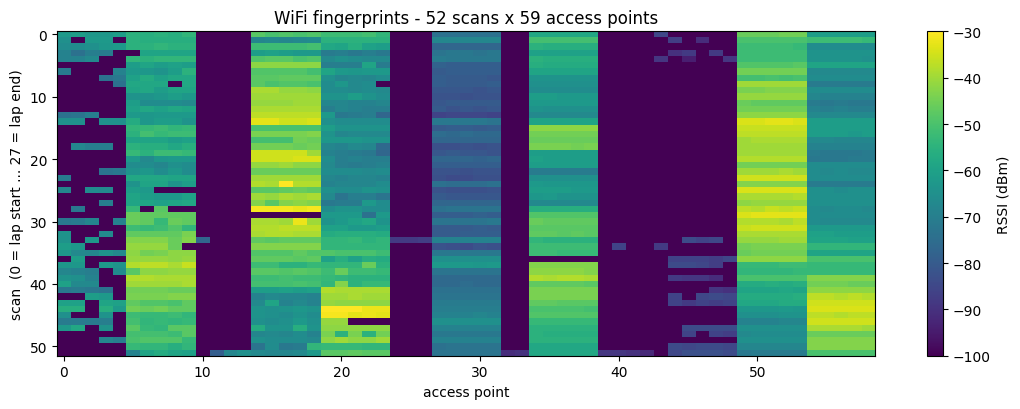

matrix (52, 59) | 36% of cells are 'not heard' (floor -100)


In [4]:
# The whole modality as one image: every scan's fingerprint. Dark = AP not heard (floor -100 dBm).
import matplotlib.pyplot as plt
M, bssids, t_ns = ds.wifi_matrix()            # (28, n_ap); stale-filtered; missing AP -> -100 dBm
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=-100, vmax=-30, interpolation="nearest")
ax.set_xlabel("access point"); ax.set_ylabel("scan  (0 = lap start ... 27 = lap end)")
ax.set_title(f"WiFi fingerprints - {M.shape[0]} scans x {M.shape[1]} access points")
fig.colorbar(im, label="RSSI (dBm)"); plt.tight_layout(); plt.show()
print(f"matrix {M.shape} | {(M==-100).mean()*100:.0f}% of cells are 'not heard' (floor -100)")

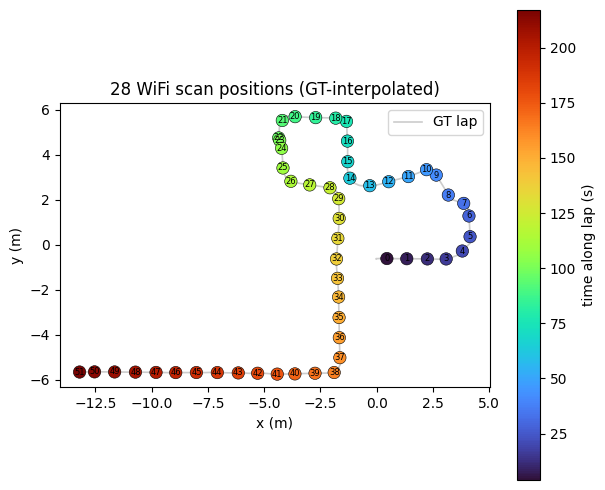

In [5]:
# Where WiFi samples the room: the 28 scan positions on the ground-truth lap.
rel = (t_ns - ds.gt.t_ns.iloc[0]) / 1e9
xs, ys, _ = ds.gt_at(t_ns)                    # GT position interpolated to each scan-end stamp
fig, ax = plt.subplots(figsize=(6.2, 5))
ax.plot(ds.gt.x, ds.gt.y, "-", color="0.8", lw=1.2, label="GT lap", zorder=1)
sc = ax.scatter(xs, ys, c=rel, cmap="turbo", s=80, zorder=3, edgecolor="k", linewidth=0.4)
for i, (x, y) in enumerate(zip(xs, ys)):
    ax.annotate(str(i), (x, y), fontsize=6, ha="center", va="center", zorder=4)
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("28 WiFi scan positions (GT-interpolated)")
fig.colorbar(sc, label="time along lap (s)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

# 2 · Does the fingerprint locate you?

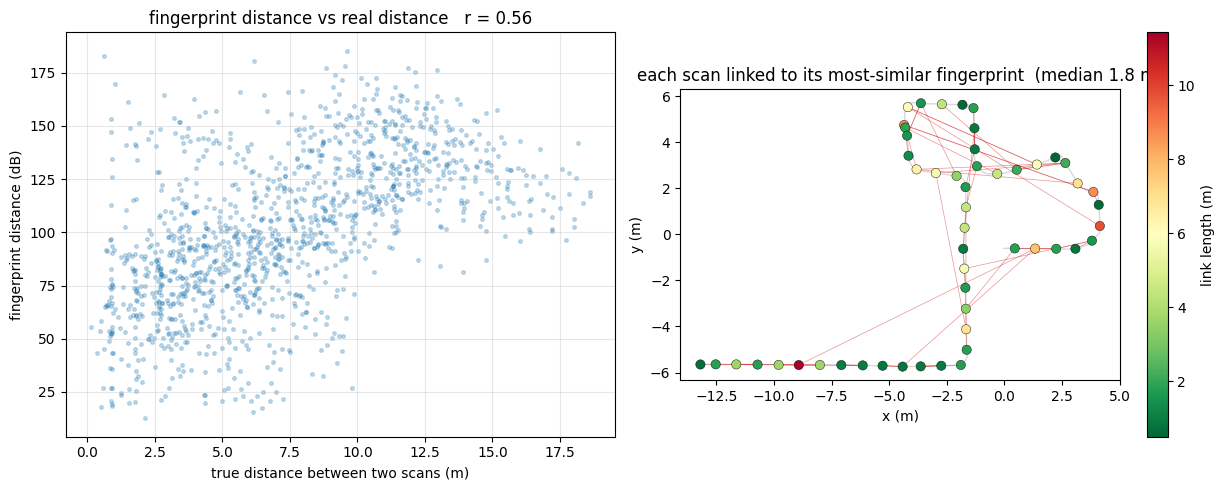

corr(fingerprint, space) = 0.56  |  nearest-fingerprint neighbour is a median 1.8 m away


In [6]:
# Similar fingerprint <-> nearby in space? The test of whether WiFi carries position at all.
M, bssids, t_ns = ds.wifi_matrix()                     # (52, n_ap) CESI, -100 fill
X, Y, _ = ds.gt_at(t_ns)                               # ground-truth position at each scan
FD = np.sqrt(((M[:, None, :] - M[None, :, :]) ** 2).sum(-1))   # fingerprint distance (dB)
SD = np.hypot(X[:, None] - X[None, :], Y[:, None] - Y[None, :])  # true spatial distance (m)
iu = np.triu_indices(len(t_ns), 1)
r = np.corrcoef(FD[iu], SD[iu])[0, 1]
nn = np.where(np.eye(len(t_ns), dtype=bool), np.inf, FD).argmin(1)   # most-similar OTHER scan
err = np.hypot(X - X[nn], Y - Y[nn])

fig, ax = plt.subplots(1, 2, figsize=(12.5, 5))
ax[0].scatter(SD[iu], FD[iu], s=7, alpha=0.25, color="tab:blue")
ax[0].set_xlabel("true distance between two scans (m)"); ax[0].set_ylabel("fingerprint distance (dB)")
ax[0].set_title(f"fingerprint distance vs real distance   r = {r:.2f}"); ax[0].grid(alpha=0.3)
ax[1].plot(ds.gt.x, ds.gt.y, "-", color="0.85", lw=1.0, zorder=1)
for i in range(len(t_ns)):
    ax[1].plot([X[i], X[nn[i]]], [Y[i], Y[nn[i]]], "-", color="tab:red", lw=0.5, alpha=0.5, zorder=2)
sc = ax[1].scatter(X, Y, c=err, cmap="RdYlGn_r", s=45, zorder=3, edgecolor="k", linewidth=0.3)
ax[1].set_aspect("equal"); ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("y (m)")
ax[1].set_title(f"each scan linked to its most-similar fingerprint  (median {np.median(err):.1f} m)")
fig.colorbar(sc, ax=ax[1], label="link length (m)"); plt.tight_layout(); plt.show()
print(f"corr(fingerprint, space) = {r:.2f}  |  nearest-fingerprint neighbour is a median {np.median(err):.1f} m away")


## 2b · Which access points carry the signal?

most discriminative APs (high RSSI spread across the route):
  ...a1:f4:51  std 11.4 dB   heard 52/52 scans
  ...a1:f4:53  std 11.4 dB   heard 52/52 scans
  ...a1:f4:52  std 11.3 dB   heard 52/52 scans
  ...a1:f4:54  std 11.3 dB   heard 52/52 scans
  ...a1:f4:50  std 11.3 dB   heard 52/52 scans
  ...61:e5:72  std 11.3 dB   heard 51/52 scans


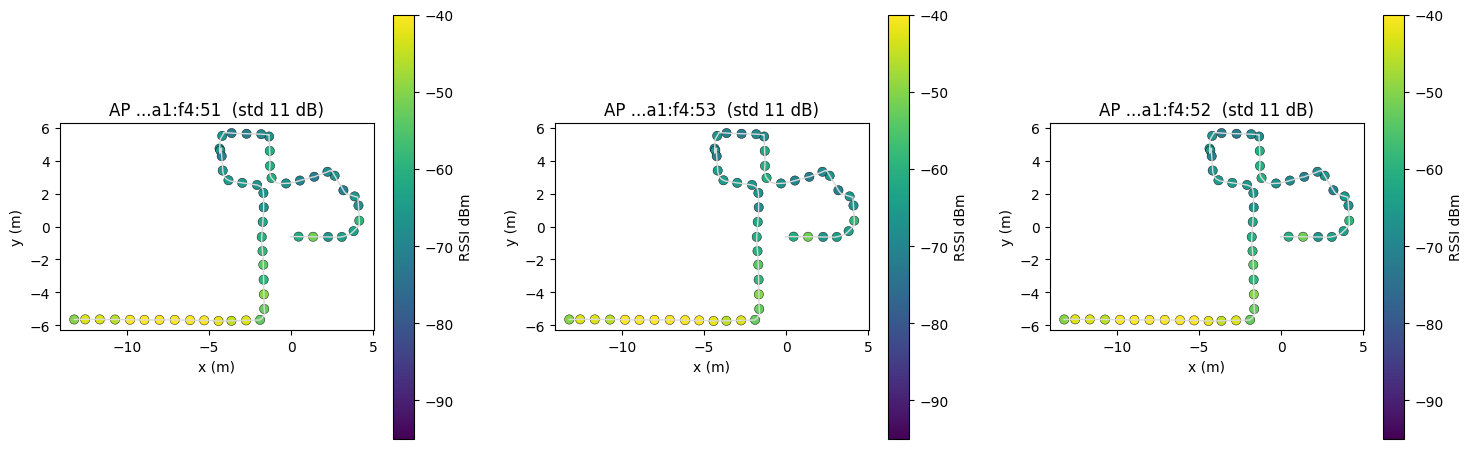

top-5 spread [11.4 11.4 11.3 11.3 11.3] dB  vs  bottom-5 [0. 0. 0. 0. 0.] dB -> a handful of room-specific APs do the work; most are seen everywhere and carry little.


In [7]:
# Rank APs by how much their RSSI moves across the route (high spread = room-specific = useful),
# then paint the top 3 on the map.
M, bssids, t_ns = ds.wifi_matrix()
X, Y, _ = ds.gt_at(t_ns)
Mm = np.where(M == -100, np.nan, M)
spread = np.nanstd(Mm, 0)                     # per-AP spatial variability (dB)
heard = (M > -100).sum(0)                     # scans that heard each AP
order = np.argsort(-spread)                   # most-variable first
print("most discriminative APs (high RSSI spread across the route):")
for j in order[:6]:
    print(f"  ...{bssids[j][-8:]}  std {spread[j]:4.1f} dB   heard {heard[j]:2d}/{len(t_ns)} scans")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, j in zip(ax, order[:3]):
    a.plot(ds.gt.x, ds.gt.y, "-", color="0.85", lw=1)
    sc = a.scatter(X, Y, c=M[:, j], cmap="viridis", vmin=-95, vmax=-40, s=45, edgecolor="k", linewidth=0.3)
    a.set_aspect("equal"); a.set_title(f"AP ...{bssids[j][-8:]}  (std {spread[j]:.0f} dB)")
    a.set_xlabel("x (m)"); a.set_ylabel("y (m)"); fig.colorbar(sc, ax=a, label="RSSI dBm")
plt.tight_layout(); plt.show()
print(f"top-5 spread {np.round(spread[order[:5]],1)} dB  vs  bottom-5 {np.round(spread[order[-5:]],1)} dB "
      f"-> a handful of room-specific APs do the work; most are seen everywhere and carry little.")

## 2c · Motion smearing during a scan

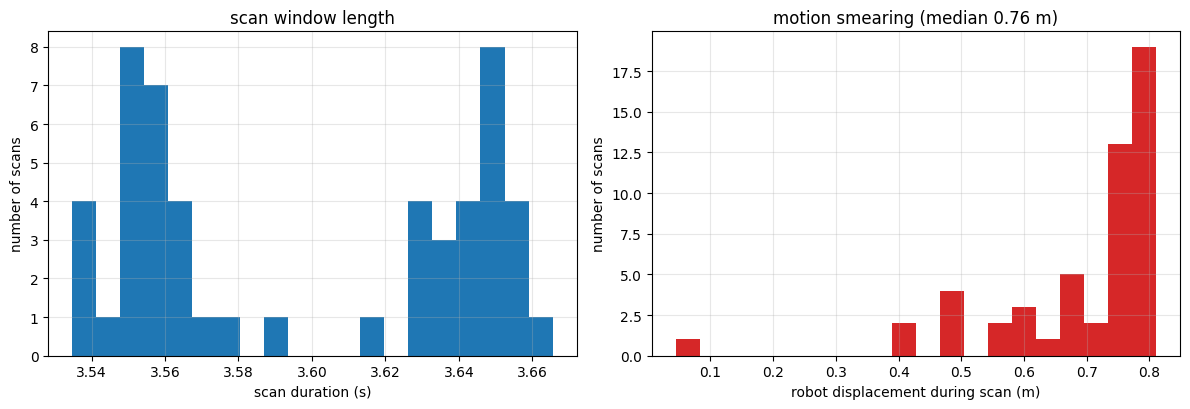

scan duration median 3.6 s; robot moves median 0.76 m (max 0.81 m) per scan -> each fingerprint is a ~0.8 m smear, a hard floor on WiFi resolution here.


In [8]:
# A scan is not instantaneous (~3.6 s of channel hopping) and the robot keeps moving, so each
# fingerprint is blurred over the path it covers during the scan window.
w = ds.wifi
sw = w.groupby("scan_idx").agg(t0=("t_start_ns", "min"), t1=("t_end_ns", "max"))
x0, y0, _ = ds.gt_at(sw.t0.values); x1, y1, _ = ds.gt_at(sw.t1.values)
disp = np.hypot(x1 - x0, y1 - y0)
dur = (sw.t1.values - sw.t0.values) / 1e9
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(dur, bins=20, color="tab:blue")
ax[0].set_xlabel("scan duration (s)"); ax[0].set_ylabel("number of scans"); ax[0].set_title("scan window length"); ax[0].grid(alpha=0.3)
ax[1].hist(disp, bins=20, color="tab:red")
ax[1].set_xlabel("robot displacement during scan (m)"); ax[1].set_ylabel("number of scans")
ax[1].set_title(f"motion smearing (median {np.median(disp):.2f} m)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"scan duration median {np.median(dur):.1f} s; robot moves median {np.median(disp):.2f} m (max {disp.max():.2f} m) per scan "
      f"-> each fingerprint is a ~{np.median(disp):.1f} m smear, a hard floor on WiFi resolution here.")

## 2d · Noise and variance in the readings

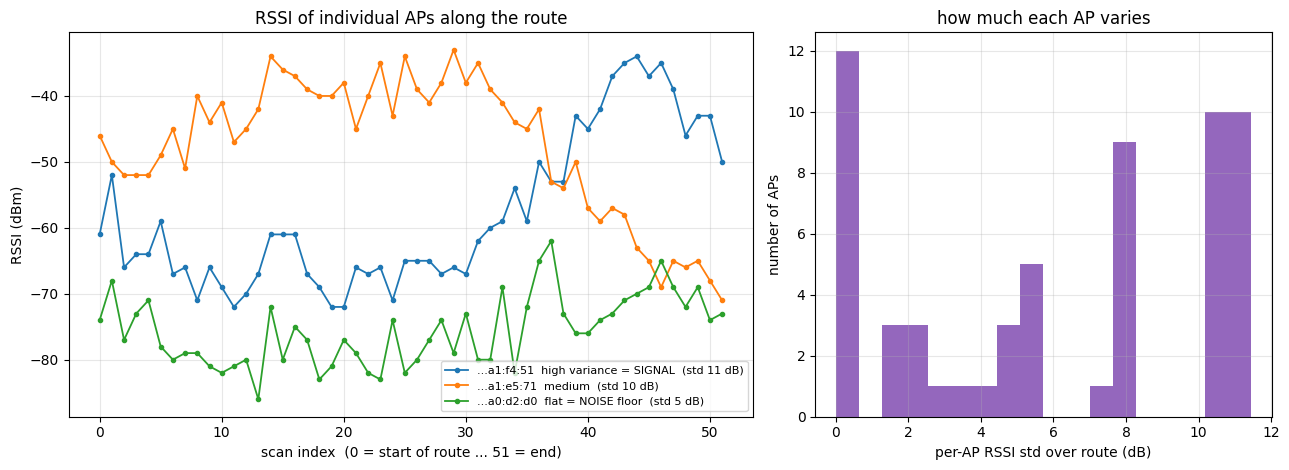

the SIGNAL AP swings 11 dB across the route; the FLAT AP wiggles ~5 dB = the noise floor. Fingerprinting works because many APs swing well above that noise.


In [9]:
# See it directly: RSSI of three APs (each heard on nearly every scan) across the 52 scans.
# One swings up-and-down a lot over the route = real spatial SIGNAL; one stays nearly flat and its
# small scan-to-scan wiggle = measurement NOISE. Right: the spread of per-AP variation.
M, bssids, t_ns = ds.wifi_matrix()
Mm = np.where(M == -100, np.nan, M)
std = np.nanstd(Mm, 0); heard = (M > -100).sum(0)
full = np.where(heard >= 45)[0]                     # only well-heard APs (so traces are complete)
fo = full[np.argsort(-std[full])]
pick = [(fo[0], "high variance = SIGNAL"), (fo[len(fo)//2], "medium"), (fo[-1], "flat = NOISE floor")]
scan = np.arange(len(t_ns))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), width_ratios=[1.5, 1])
for j, lab in pick:
    ax[0].plot(scan, Mm[:, j], "-o", ms=3, lw=1.3, label=f"...{bssids[j][-8:]}  {lab}  (std {std[j]:.0f} dB)")
ax[0].set_xlabel("scan index  (0 = start of route ... 51 = end)"); ax[0].set_ylabel("RSSI (dBm)")
ax[0].set_title("RSSI of individual APs along the route"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].hist(std[np.isfinite(std)], bins=18, color="tab:purple")
ax[1].set_xlabel("per-AP RSSI std over route (dB)"); ax[1].set_ylabel("number of APs")
ax[1].set_title("how much each AP varies"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"the SIGNAL AP swings {std[fo[0]]:.0f} dB across the route; the FLAT AP wiggles ~{std[fo[-1]]:.0f} dB = the noise floor. "
      f"Fingerprinting works because many APs swing well above that noise.")

# 3 · Methods — WiFi localization

Two protocols, mirroring the camera notebook. **A (in-map):** interleaved 4-fold — every scan predicted by a model that never saw it (interpolation). **B (out-of-map):** time-forward 60/40 — train the first 60 % of the route, test the last 40 % (extrapolation to unseen space).

In [10]:
# --- harness: fingerprint matrix, GT positions, protocols, scoring ---
import pandas as pd
M, bssids, t_ns = ds.wifi_matrix()                    # (52, n_ap) CESI, -100 = not heard
gx, gy, _ = ds.gt_at(t_ns); XY = np.c_[gx, gy]; N = len(t_ns)
K = 4
foldA = np.arange(N) % K                              # A: interleaved 4-fold (interpolation)
splitB = int(round(0.60 * N))                         # B: time-forward (train first 60%, test last 40%)
RESULTS = {}
PRED = {}    # per-method protocol-A predictions, for the map view
def report(name, predA, predB, show=True):
    eA = np.hypot(predA[:,0]-XY[:,0], predA[:,1]-XY[:,1])
    eB = np.hypot(predB[:,0]-XY[splitB:,0], predB[:,1]-XY[splitB:,1])
    RESULTS[name] = dict(A_med=float(np.median(eA)), A_mean=float(eA.mean()), A_acc2m=float((eA<=2).mean()*100),
                         B_med=float(np.median(eB)), B_mean=float(eB.mean()))
    PRED[name] = predA.copy()
    if show: print(f"{name:10s} A(in-map) med {np.median(eA):4.2f} m  mean {eA.mean():4.2f}  <=2m {(eA<=2).mean():3.0%}"
                   f"   |   B(fwd) med {np.median(eB):4.2f} m  mean {eB.mean():4.2f}")
def by_protocol(predict):
    pA = np.zeros((N, 2))
    for f in range(K):
        tr, te = foldA != f, foldA == f
        pA[te] = predict(M[tr], XY[tr], M[te])
    pB = predict(M[:splitB], XY[:splitB], M[splitB:])
    return pA, pB
print(f"protocol A: {K} interleaved folds over {N} scans | protocol B: train {splitB} / test {N-splitB}")

protocol A: 4 interleaved folds over 52 scans | protocol B: train 31 / test 21


## 3a · Baselines — RADAR, Weighted-kNN, Horus (RSSI-only, memory-based)

In [11]:
# The three must-cite classics. All RSSI-only, no training beyond storing fingerprints.
def knn(Mtr, Ptr, Mte, k=1, weighted=False, rep=lambda m: m):
    A, B = rep(Mtr), rep(Mte)
    D = np.sqrt(((B[:, None, :] - A[None, :, :]) ** 2).sum(-1))     # distance in (repped) RSS space
    nn = np.argsort(D, 1)[:, :k]; dn = np.take_along_axis(D, nn, 1)
    if weighted:
        w = 1.0 / (dn + 1e-9); w /= w.sum(1, keepdims=True)
        return (w[:, :, None] * Ptr[nn]).sum(1)
    return Ptr[nn].mean(1)
powed = lambda m: ((np.clip(m, -100, -20) + 100) / 80.0) ** np.e    # Torres-Sospedra "powed" RSS representation

def horus(Mtr, Ptr, Mte, cell=1.5, sigma=6.0):                      # probabilistic: per-cell Gaussian likelihood
    key = np.floor(Ptr / cell).astype(int)
    _, inv = np.unique(key, axis=0, return_inverse=True); Cn = inv.max() + 1
    mu = np.stack([Mtr[inv == c].mean(0) for c in range(Cn)])       # per-cell mean fingerprint
    cen = np.stack([Ptr[inv == c].mean(0) for c in range(Cn)])      # per-cell centroid
    ll = -((Mte[:, None, :] - mu[None, :, :]) ** 2).sum(-1) / (2 * sigma ** 2)
    return cen[ll.argmax(1)]

report("RADAR", *by_protocol(lambda a, b, c: knn(a, b, c, k=1)))                        # kNN, Euclidean, k=1
report("WkNN",  *by_protocol(lambda a, b, c: knn(a, b, c, k=5, weighted=True, rep=powed)))  # weighted, powed, k=5
report("Horus", *by_protocol(horus))                                                    # probabilistic

RADAR      A(in-map) med 1.82 m  mean 3.29  <=2m 54%   |   B(fwd) med 8.50 m  mean 8.88
WkNN       A(in-map) med 1.72 m  mean 1.96  <=2m 58%   |   B(fwd) med 8.31 m  mean 9.05
Horus      A(in-map) med 1.86 m  mean 2.79  <=2m 54%   |   B(fwd) med 8.01 m  mean 8.90


## 3b · Deep competitors — CNNLoc & Kim (official code, isolated sub-venvs)

Two recent WiFi-fingerprinting deep nets, run as their **authors published them**. Each lives in its own legacy environment (Python 3.7 / TensorFlow 1.15 / Keras 2.2.5) and talks to this notebook over `.npz` — no edits to their model code. **CNNLoc** (Song et al., IEEE Access 2019) is a stacked auto-encoder + 1D-CNN; we drive its positioning-regression path. **Kim** (Kim et al., Big Data Analytics 2018) is a stacked auto-encoder + classifier; single-floor here, so we keep their SAE recipe unchanged and swap the classifier for the 2-output (x,y) head their paper's regression variant uses. Both were built for thousands of fingerprints across many floors — on 52 scans they are expected to **overfit** and trail the memory-based baselines. The point is a fair, reproducible pipeline that will re-run untouched on the full dataset.

In [12]:
# Each competitor runs UNCHANGED in its own Py3.7/TF1.15 venv; we marshal fingerprints + GT in, (x,y) out.
import subprocess, tempfile
SOTA = {
    "CNNLoc": ("/root/navlori/venvs_wifi/cnnloc/bin/python",
               "/root/navlori/mrepos_wifi/cnnloc/cnnloc_runner.py", "/root/navlori/mrepos_wifi/cnnloc"),
    "Kim":    ("/root/navlori/venvs_wifi/kim/bin/python",
               "/root/navlori/mrepos_wifi/kimdnn/kim_runner.py", None),
}
def pad520(m):                                   # both nets expect the 520-AP UJIIndoorLoc layout
    z = np.full((m.shape[0], 520), -100.0); z[:, :m.shape[1]] = m; return z   # -100 = not heard
def sota_predict(name):
    py, runner, cwd = SOTA[name]
    def predict(Mtr, Ptr, Mte):
        with tempfile.TemporaryDirectory() as td:
            ip, op = td + "/in.npz", td + "/out.npz"
            np.savez(ip, Xtr=pad520(Mtr), ytr=np.c_[Ptr, np.zeros((len(Ptr), 2))], Xte=pad520(Mte))
            subprocess.run([py, runner, ip, op], cwd=cwd, check=True,
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return np.load(op)["pred"]                                     # (m,2) = [x,y] metres
    return predict

report("CNNLoc", *by_protocol(sota_predict("CNNLoc")))   # ~5 fits per protocol; a few minutes
report("Kim",    *by_protocol(sota_predict("Kim")))

CNNLoc     A(in-map) med 3.40 m  mean 3.79  <=2m 23%   |   B(fwd) med 12.29 m  mean 11.53


Kim        A(in-map) med 2.28 m  mean 2.85  <=2m 46%   |   B(fwd) med 10.79 m  mean 11.96


## 3c · Results — five methods, two protocols

**A (in-map)** = can it place a scan inside the surveyed route; **B (fwd)** = can it extrapolate to space it never trained on. The gap between the two columns is the real lesson.

,A med (m),A mean,A ≤2m %,B med (m),B mean
method,,,,,
RADAR,1.82,3.29,53.85,8.50,8.88
WkNN,1.72,1.96,57.69,8.31,9.05
Horus,1.86,2.79,53.85,8.01,8.90
CNNLoc,3.40,3.79,23.08,12.29,11.53
Kim,2.28,2.85,46.15,10.79,11.96


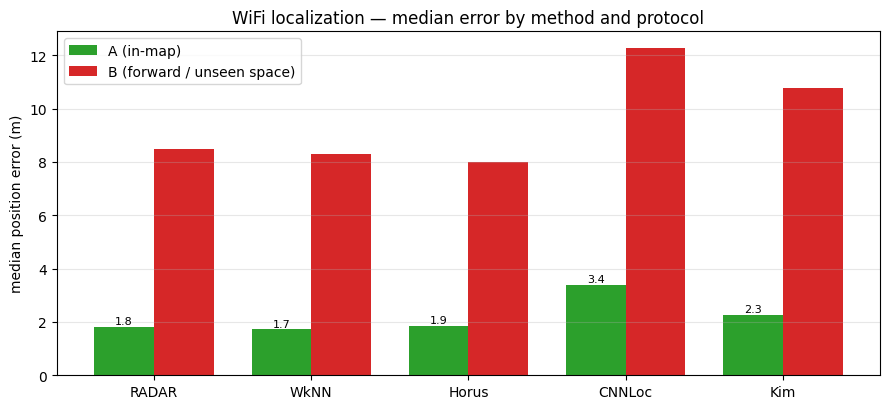

In-map winner: WkNN (1.72 m median). The deep nets overfit on 52 scans; forward to unseen space (B) all methods sit ~8-10 m -> WiFi maps what it has seen, it does not extrapolate.


In [13]:
import pandas as pd
from IPython.display import display
order = ["RADAR", "WkNN", "Horus", "CNNLoc", "Kim"]
cols  = {"A_med":"A med (m)", "A_mean":"A mean", "A_acc2m":"A ≤2m %", "B_med":"B med (m)", "B_mean":"B mean"}
df = pd.DataFrame([{"method": k, **RESULTS[k]} for k in order if k in RESULTS]).set_index("method")[list(cols)].rename(columns=cols)
display(df.round(2))

x = np.arange(len(df)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - w/2, df["A med (m)"], w, label="A (in-map)", color="tab:green")
ax.bar(x + w/2, df["B med (m)"], w, label="B (forward / unseen space)", color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(df.index); ax.set_ylabel("median position error (m)")
ax.set_title("WiFi localization — median error by method and protocol"); ax.legend(); ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(df["A med (m)"]): ax.text(i - w/2, v + 0.1, f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
best = df["A med (m)"].idxmin()
print(f"In-map winner: {best} ({df.loc[best,'A med (m)']:.2f} m median). The deep nets overfit on 52 scans; "
      f"forward to unseen space (B) all methods sit ~8-10 m -> WiFi maps what it has seen, it does not extrapolate.")

## 3d · On the map — where each method puts you

Protocol A (in-map). Black = true scan position, blue = the method's estimate, red = the error it makes. Walls in grey. The baselines snap tightly to the route; the deep nets scatter — the same overfitting the table shows, made spatial.

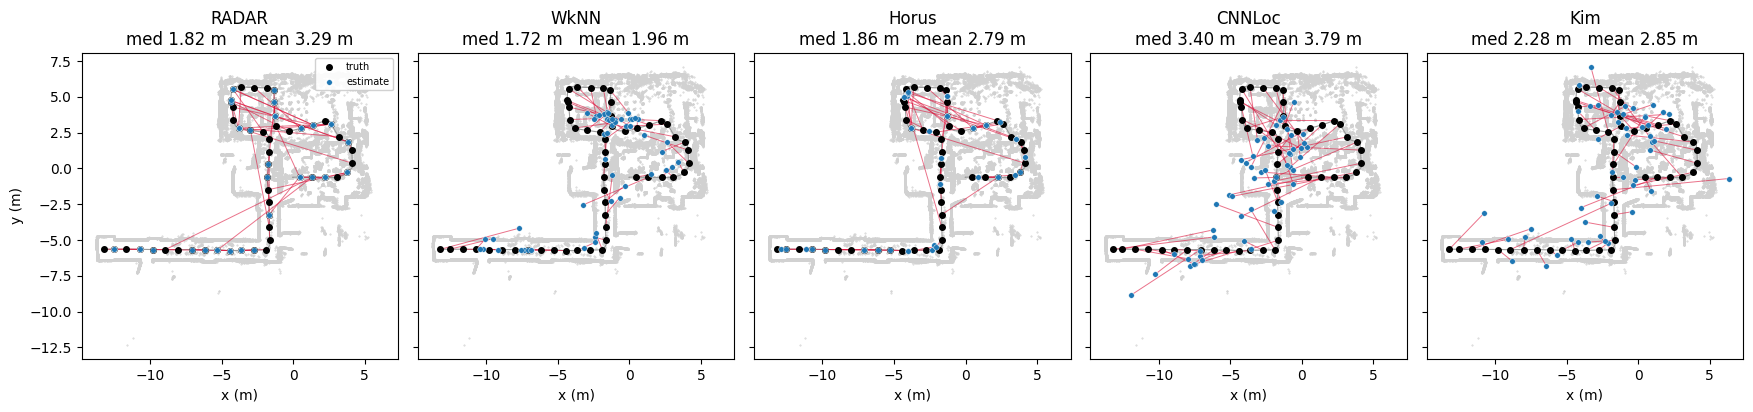

red segments = per-scan error. Short & radial around the route -> good; long strays -> the estimate jumped to the wrong part of the building (mostly the two deep nets on this 52-scan set).


In [14]:
methods = [m for m in ["RADAR", "WkNN", "Horus", "CNNLoc", "Kim"] if m in PRED]
walls = np.load(f"{DATA}/ground_truth/map_points.npz")["xy"]
fig, axes = plt.subplots(1, len(methods), figsize=(3.5 * len(methods), 4.4), sharex=True, sharey=True)
for ax, name in zip(axes, methods):
    P = PRED[name]; e = np.hypot(P[:, 0] - XY[:, 0], P[:, 1] - XY[:, 1])
    ax.scatter(walls[:, 0], walls[:, 1], s=0.2, c="0.82", zorder=0)          # floor plan
    ax.plot(ds.gt.x, ds.gt.y, "-", color="0.6", lw=0.8, zorder=1)            # driven route
    for (px, py), (tx, ty) in zip(P, XY):
        ax.plot([tx, px], [ty, py], "-", color="crimson", lw=0.7, alpha=0.6, zorder=2)   # error
    ax.scatter(XY[:, 0], XY[:, 1], s=16, c="k", zorder=3, label="truth")
    ax.scatter(P[:, 0], P[:, 1], s=16, c="tab:blue", edgecolor="w", linewidth=0.3, zorder=4, label="estimate")
    ax.set_aspect("equal"); ax.set_xlabel("x (m)")
    ax.set_title(f"{name}\nmed {np.median(e):.2f} m   mean {e.mean():.2f} m")
axes[0].set_ylabel("y (m)"); axes[0].legend(loc="upper right", fontsize=7, framealpha=0.9)
plt.tight_layout(); plt.show()
print("red segments = per-scan error. Short & radial around the route -> good; long strays -> the estimate "
      "jumped to the wrong part of the building (mostly the two deep nets on this 52-scan set).")

## 3e · Real time — the robot drives, every method guesses

The same five methods, played back along the route. The black star is the robot; as each WiFi scan fires, each panel drops that method's estimate (blue) with a red line to the truth, and its running median updates. Watch the baselines track the robot while the deep nets fling estimates across the floor — the table's numbers, in motion.

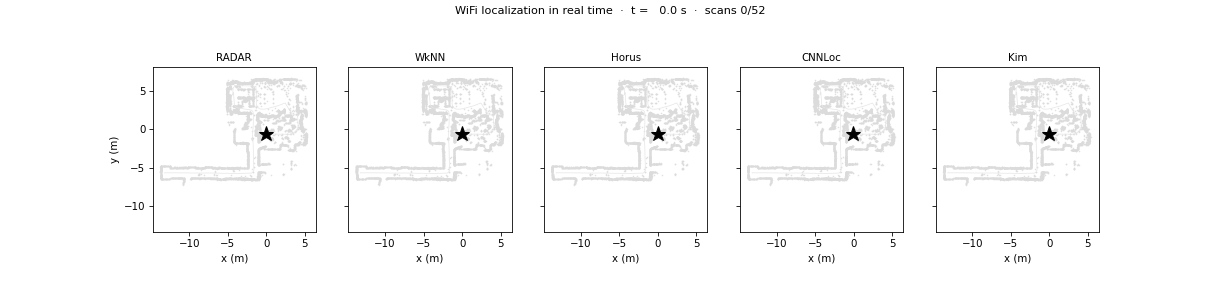

In [15]:
# Reuses PRED (protocol A) from above; builds an animated GIF and embeds it.
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
import tempfile

methods = [m for m in ["RADAR", "WkNN", "Horus", "CNNLoc", "Kim"] if m in PRED]
walls = np.load(f"{DATA}/ground_truth/map_points.npz")["xy"]; wsub = walls[::12]
gt_t = ds.gt.t_ns.values.astype(float); gt_x = ds.gt.x.values; gt_y = ds.gt.y.values
FRAMES = 80; ft = np.linspace(gt_t[0], gt_t[-1], FRAMES)
xlim = (walls[:, 0].min() - 1, walls[:, 0].max() + 1); ylim = (walls[:, 1].min() - 1, walls[:, 1].max() + 1)

fig, axes = plt.subplots(1, len(methods), figsize=(3.3 * len(methods), 4.0), sharex=True, sharey=True, dpi=74)
art = []
for ax, name in zip(axes, methods):
    ax.scatter(wsub[:, 0], wsub[:, 1], s=0.2, c="0.86", zorder=0)
    ax.plot(gt_x, gt_y, "-", color="0.9", lw=0.7, zorder=1)
    route, = ax.plot([], [], "-", color="0.55", lw=1.2, zorder=2)
    errs = [ax.plot([], [], "-", color="crimson", lw=0.8, alpha=0.55, zorder=3)[0] for _ in range(N)]
    past = ax.scatter([], [], s=12, c="tab:blue", alpha=0.35, zorder=4)
    cur, = ax.plot([], [], "o", ms=8, color="tab:blue", mec="w", mew=0.6, zorder=6)
    robot, = ax.plot([], [], "*", ms=15, color="k", zorder=7)
    ttl = ax.set_title(name, fontsize=10)
    ax.set_aspect("equal"); ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_xlabel("x (m)")
    art.append(dict(name=name, route=route, errs=errs, past=past, cur=cur, robot=robot, ttl=ttl))
axes[0].set_ylabel("y (m)"); sup = fig.suptitle("", fontsize=11)

def update(fi):
    tau = ft[fi]; fired = int((t_ns <= tau).sum())
    rx = np.interp(tau, gt_t, gt_x); ry = np.interp(tau, gt_t, gt_y); gm = gt_t <= tau
    for a in art:
        P = PRED[a["name"]]
        a["route"].set_data(gt_x[gm], gt_y[gm]); a["robot"].set_data([rx], [ry])
        if fired:
            a["past"].set_offsets(P[:fired]); a["cur"].set_data([P[fired - 1, 0]], [P[fired - 1, 1]])
            for k in range(N):
                a["errs"][k].set_data([XY[k, 0], P[k, 0]], [XY[k, 1], P[k, 1]]) if k < fired else a["errs"][k].set_data([], [])
            e = np.hypot(P[:fired, 0] - XY[:fired, 0], P[:fired, 1] - XY[:fired, 1])
            a["ttl"].set_text(f"{a['name']}   med {np.median(e):.2f} m")
    sup.set_text(f"WiFi localization in real time  ·  t = {(tau - gt_t[0]) / 1e9:5.1f} s  ·  scans {fired}/{N}")
    return []

anim = FuncAnimation(fig, update, frames=FRAMES, blit=False)
gif = tempfile.mkstemp(suffix=".gif")[1]
anim.save(gif, writer=PillowWriter(fps=10)); plt.close(fig)
Image(filename=gif)